# Quickstart Guide - CHIME/FRB Selection Function
### Author: Kyle McGregor (McGill University)

This notebook demonstrates usage of the `chimefrb_selection` package to:
- Compute selection probabilities and Horvitz–Thompson (HT) weights.
- Work with both single bursts and vectorized inputs.
- Configure reduced-dimensional selection functions.
- Plot 1D, 2D, and 3D examples of the selection function.

Each section includes a short explanation of what the code does and what to look for in the output.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import chimefrb_selection as cfsf

## Single burst probability and weight

Here we calculate the detection probability and HT weight for **one burst** with given parameters.  
The `return_std=True` option provides approximate uncertainties.

In [2]:
# These all load the default best-fit model (see model-selection.ipynb)
sf_default = cfsf.SelectionFunction()
sf_default = cfsf.SelectionFunction(predictor_names=['fluence','scattering_time','width','dm']) 
sf_default = cfsf.SelectionFunction(predictor_names=['fluence','scattering_time','width','dm'],
                                    degree=3,
                                    snr_cut=12.0,
                                    exclude_sidelobes=True,
                                    sidelobe_cut=5.0)

# Calculate selection probability for a given FRB 
p, p_std = sf_default.calculate_selection_probability({'fluence_jy_ms':5.0,
                                                        'tau_1_ghz_ms':1e-2,
                                                        'pulse_width_ms':1.0,
                                                        'dm':500},
                                                        return_std=True)

# Calculate its Horvitz-Thompson (inverse probability) weight
w, w_std = sf_default.calculate_ht_weight({'fluence_jy_ms':5.0,
                                            'tau_1_ghz_ms':1e-2,
                                            'pulse_width_ms':1.0,
                                            'dm':500},
                                            return_std=True)

print(f"Selection probability: {p:.3f} +/- {p_std:.3f}")
print(f"HT weight: {w:.3f} +/- {w_std:.3f}")

/home/kmcgregor/chimefrb-selection/chimefrb_selection/selection.py:127: RuntimeWarning: 4D selection functions are not reweighted; forcing reweighted=False
  warnings.warn(
/home/kmcgregor/chimefrb-selection/chimefrb_selection/selection.py:127: RuntimeWarning: 4D selection functions are not reweighted; forcing reweighted=False
  warnings.warn(
/home/kmcgregor/chimefrb-selection/chimefrb_selection/selection.py:127: RuntimeWarning: 4D selection functions are not reweighted; forcing reweighted=False
  warnings.warn(


Selection probability: 0.365 +/- 0.005
HT weight: 2.740 +/- 0.041


## Vectorized evaluation

The functions also work on arrays of burst properties.  
Here we generate random bursts and compute probabilities and weights for each of them.

In [10]:
burst_properties = {'fluence_jy_ms':np.random.uniform(1,10,int(1e5)),
                    'tau_1_ghz_ms':np.random.uniform(1e-4,1e0,int(1e5)),
                    'pulse_width_ms':np.random.uniform(0.5,0.65,int(1e5)),
                    'dm':np.random.uniform(500,1000,int(1e5))}

p_vec, p_vec_std = sf_default.calculate_selection_probability(burst_properties, return_std=True)
w_vec, w_vec_std = sf_default.calculate_ht_weight(burst_properties, return_std=True)

print(p_vec)
print(p_vec_std)
print(w_vec)
print(w_vec_std)

[nan nan nan nan nan nan nan nan nan]
[2.29210722e-03 5.98753967e-05 2.18497386e-03 ... 5.37841016e-05
 9.23213932e-04 1.50330470e-03]
[  2.83976173 849.58038668   2.88256446 ... 808.87580266  12.35850231
   9.77405878]
[1.84841180e-02 4.32172730e+01 1.81553364e-02 ... 3.51898654e+01
 1.41004845e-01 1.43614043e-01]


In [11]:
from tqdm import tqdm

for i in tqdm(range(int(1e5))):
    p, p_std = sf_default.calculate_selection_probability({'fluence_jy_ms':5.0,
                                                        'tau_1_ghz_ms':1e-2,
                                                        'pulse_width_ms':1.0,
                                                        'dm':500},
                                                        return_std=True)


  0%|          | 49/100000 [00:00<03:25, 485.65it/s]

100%|██████████| 100000/100000 [02:42<00:00, 616.16it/s]


## Reduced-dimensional selection function

You can construct selection functions in fewer dimensions.  
This example marginalizes over DM by leaving it out of the predictors.

In [4]:
sf_dm_marg = cfsf.SelectionFunction(predictor_names=['fluence','scattering_time','width'],
                                    degree=3,
                                    snr_cut=12.0,
                                    exclude_sidelobes=True,
                                    sidelobe_cut=5.0)

burst_properties_dm_marg = {'fluence_jy_ms':np.random.uniform(1,10,5),
                        'tau_1_ghz_ms':np.random.uniform(1e-3,1e-1,5),
                        'pulse_width_ms':np.random.uniform(0.5,5.0,5)}

p_dm_marg, p_dm_marg_std = sf_dm_marg.calculate_selection_probability(burst_properties_dm_marg, return_std=True)
w_dm_marg, w_dm_marg_std = sf_dm_marg.calculate_ht_weight(burst_properties_dm_marg, return_std=True)
print(p_dm_marg)
print(p_dm_marg_std)
print(w_dm_marg)
print(w_dm_marg_std)

[0.34495573 0.15890645 0.11364962 0.15879629 0.33733692]
[0.01475319 0.00195162 0.01228257 0.00234503 0.00345897]
[2.89892267 6.29301093 8.79897323 6.29737648 2.96439538]
[0.12398214 0.07728788 0.95094023 0.09299686 0.03039622]


In [4]:
from tqdm import tqdm

for i in tqdm(range(int(1e6))):
    sf_default.calculate_selection_probability({'fluence_jy_ms':5.0,
                                            'tau_1_ghz_ms':1e-2,
                                            'pulse_width_ms':1.0,
                                            'dm':500})

  1%|          | 12095/1000000 [00:18<24:57, 659.74it/s]


KeyboardInterrupt: 

## 1D plots: scattering vs DM

This section plots detection probability as a function of DM for different scattering times.  
Each curve shows how the selection probability changes with DM at fixed scattering time.

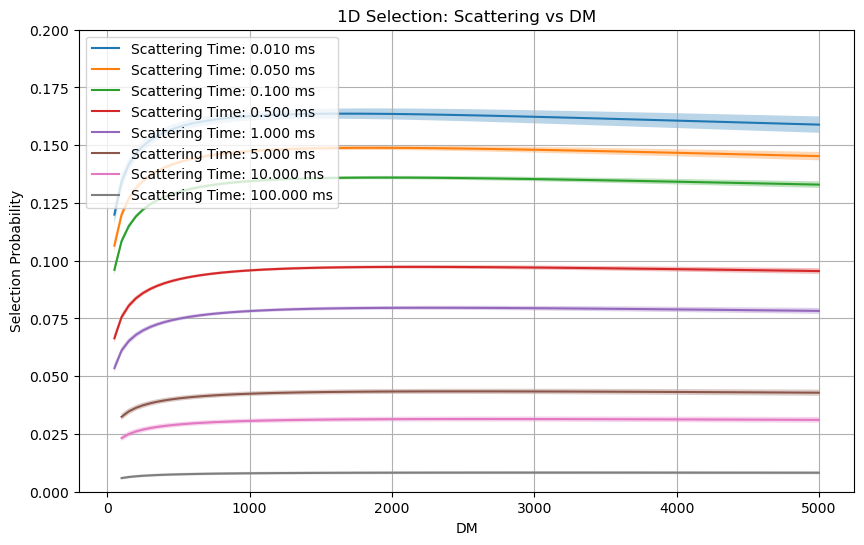

In [5]:
sf_scattering_dm = cfsf.SelectionFunction(
        predictor_names=['scattering_time','dm'],
        degree=2,
        snr_cut=12.0,
        exclude_sidelobes=True,
        sidelobe_cut=5.0)

dm = np.linspace(0, 5000, 100)
plt.figure(figsize=(10, 6))

for scat_time in [0.01, 0.05, 0.1, 0.5, 1., 5., 10., 100.]:
    selection_probabilities = []
    uncertainties = []
    for dm_val in dm:
        try:
            prob, prob_std = sf_scattering_dm.calculate_selection_probability({'scattering_time': scat_time, 'dm': dm_val}, return_std=True)
        except ValueError:
            prob, prob_std = np.nan, np.nan
        selection_probabilities.append(prob)
        uncertainties.append(prob_std)
    selection_probabilities = np.array(selection_probabilities)
    uncertainties = np.array(uncertainties)
    plt.plot(dm, selection_probabilities, label=f'Scattering Time: {scat_time:.3f} ms')
    plt.fill_between(dm, selection_probabilities - uncertainties, selection_probabilities + uncertainties, alpha=0.3)

plt.xlabel('DM')
plt.ylabel('Selection Probability')
plt.title('1D Selection: Scattering vs DM')
plt.ylim(0, 0.2)
plt.legend()
plt.grid()
plt.show()

## 2D plots: fluence vs scattering

Here we calculate selection probabilities across a 2D grid of fluence and scattering times, fixing DM and width.  
The result is shown as a color map.

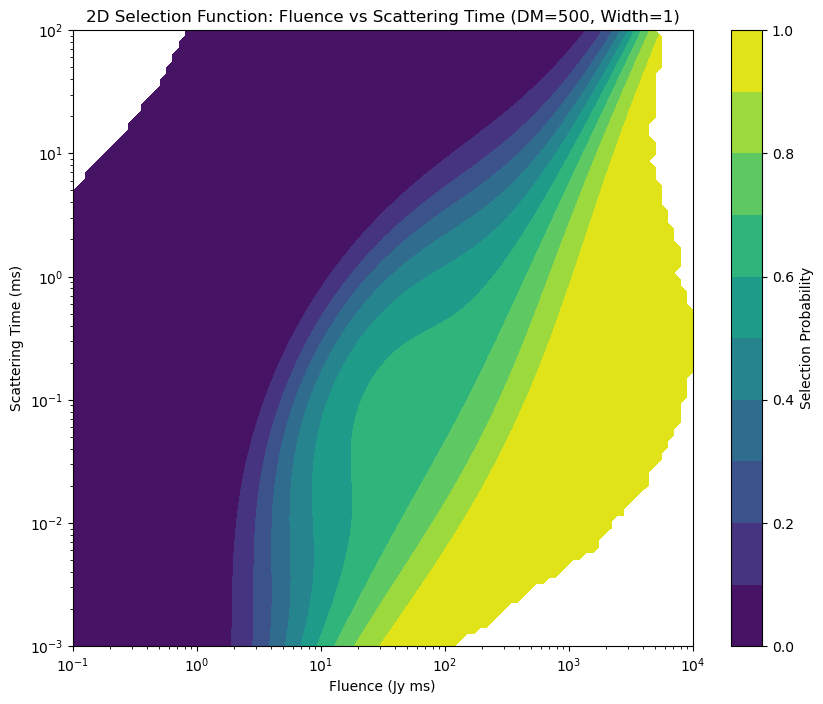

In [6]:
fluence_grid = np.logspace(-1, 4, 100)
scattering_time_grid = np.logspace(-3, 2, 100)
fluence_mesh, scattering_time_mesh = np.meshgrid(fluence_grid, scattering_time_grid)

selection_probabilities_2d = np.zeros_like(fluence_mesh)
for i in range(fluence_mesh.shape[0]):
    for j in range(fluence_mesh.shape[1]):
        try:
            selection_probabilities_2d[i, j] = sf_default.calculate_selection_probability({
                'fluence_jy_ms': fluence_mesh[i, j],
                'tau_1_ghz_ms': scattering_time_mesh[i, j],
                'pulse_width_ms': 1.0,
                'dm': 500})
        except ValueError:
            selection_probabilities_2d[i, j] = np.nan

plt.figure(figsize=(10, 8))
plt.contourf(fluence_mesh, scattering_time_mesh, selection_probabilities_2d, levels=10, cmap='viridis')
plt.xscale('log')
plt.yscale('log')
plt.colorbar(label='Selection Probability')
plt.xlabel('Fluence (Jy ms)')
plt.ylabel('Scattering Time (ms)')
plt.title('2D Selection Function: Fluence vs Scattering Time (DM=500, Width=1)')
plt.show()

## 1D slices of 4D function

We can also explore slices through the full 4D selection function.  
Here we plot probability vs DM for different scattering times, keeping fluence and width fixed.

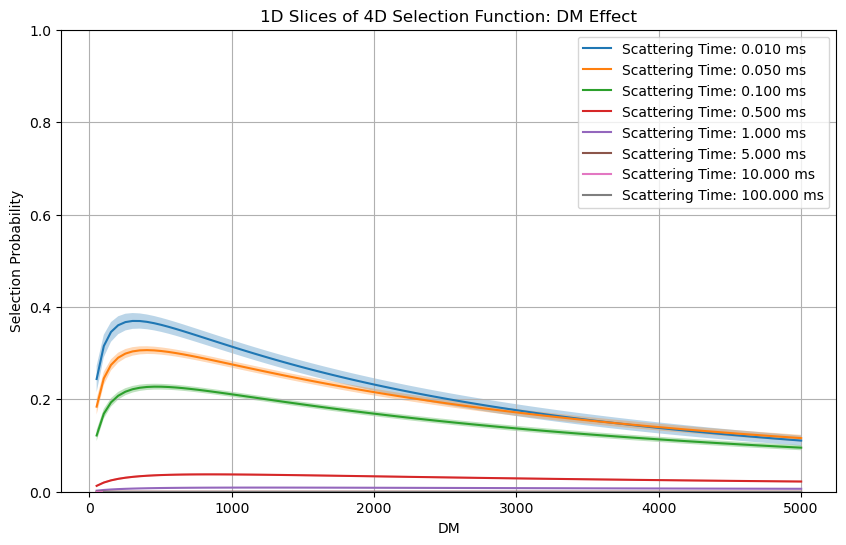

In [7]:
plt.figure(figsize=(10, 6))
scattering_times = [0.01, 0.05, 0.1, 0.5, 1., 5., 10., 100.]

for scat_time in scattering_times:
    selection_probabilities = []
    uncertainties = []
    for dm_val in dm:
        try:
            prob, prob_std = sf_default.calculate_selection_probability({
                'fluence_jy_ms': 5.0,
                'tau_1_ghz_ms': scat_time,
                'pulse_width_ms': 0.05,
                'dm': dm_val}, return_std=True)
        except ValueError:
            prob, prob_std = np.nan, np.nan
        selection_probabilities.append(prob)
        uncertainties.append(prob_std)
    selection_probabilities = np.array(selection_probabilities)
    uncertainties = np.array(uncertainties)
    plt.plot(dm, selection_probabilities, label=f'Scattering Time: {scat_time:.3f} ms')
    plt.fill_between(dm, selection_probabilities - uncertainties, selection_probabilities + uncertainties, alpha=0.3)

plt.xlabel('DM')
plt.ylabel('Selection Probability')
plt.title('1D Slices of 4D Selection Function: DM Effect')
plt.ylim(0, 1)
plt.legend()
plt.grid()
plt.show()

## 3D volumetric rendering

Finally, here is a 3D plot using Plotly to visualize the function across fluence, width, and scattering time.  
The volumetric rendering shows isosurfaces of constant detection probability.

In [ ]:
import plotly.graph_objects as go

fluence_grid = np.logspace(-1, 4, 50)
width_grid = np.logspace(-2, 3, 50)
scattering_time_grid = np.logspace(-3, 2, 50)

fluence_mesh, width_mesh, scattering_time_mesh = np.meshgrid(fluence_grid, width_grid, scattering_time_grid, indexing='ij')
burst_properties_3d = {
    'fluence_jy_ms': fluence_mesh.flatten(),
    'tau_1_ghz_ms': scattering_time_mesh.flatten(),
    'pulse_width_ms': width_mesh.flatten(),
    'dm': np.full(fluence_mesh.size, 500)
}

valid_indices = sf_default.contains(burst_properties_3d)
for key in burst_properties_3d:
    burst_properties_3d[key] = burst_properties_3d[key][valid_indices]

selection_probabilities_flat = sf_default.calculate_selection_probability(burst_properties_3d)
selection_probabilities_flat = np.nan_to_num(selection_probabilities_flat, nan=0.0)

selection_probabilities_3d = np.full(fluence_mesh.shape, np.nan)
selection_probabilities_3d.flat[np.where(valid_indices)] = selection_probabilities_flat

fig = go.Figure(data=go.Volume(
    x=fluence_mesh.flatten(),
    y=width_mesh.flatten(),
    z=scattering_time_mesh.flatten(),
    value=np.nan_to_num(selection_probabilities_3d.flatten(), nan=0.0),
    isomin=0.0,
    isomax=np.nanmax(selection_probabilities_3d),
    opacity=0.1,
    surface_count=20,
    colorscale='Viridis',
    colorbar=dict(title='Selection Probability')
))

fig.update_layout(
    scene=dict(
        xaxis_title='Fluence (Jy ms)',
        yaxis_title='Width (ms)',
        zaxis_title='Scattering Time (ms)',
        xaxis=dict(type='log'),
        yaxis=dict(type='log'),
        zaxis=dict(type='log')
    ),
    title='3D Volumetric Rendering of Selection Effect',
    width=800,
    height=800
)
fig.show()